In [1]:
# Importing normal libraries
import numpy as np 
from numpy.random import randn
import pandas as pd
from pandas import Series, DataFrame

from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [2]:
# Loading the dataset from local drive 'D'

df_anime = pd.read_csv(r'D:\Datasets\anime dataset\animes.csv')

df_anime.head()

,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link
0,28891,Haikyuu!! Second Season,Following their participation at the Inter-Hig...,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/766...,https://myanimelist.net/anime/28891/Haikyuu_Se...
1,23273,Shigatsu wa Kimi no Uso,Music accompanies the path of the human metron...,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/671...,https://myanimelist.net/anime/23273/Shigatsu_w...
2,34599,Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...,https://myanimelist.net/anime/34599/Made_in_Abyss
3,5114,Fullmetal Alchemist: Brotherhood,"""In order for something to be obtained, someth...","['Action', 'Military', 'Adventure', 'Comedy', ...","Apr 5, 2009 to Jul 4, 2010",64.0,1615084,4,1.0,9.23,https://cdn.myanimelist.net/images/anime/1223/...,https://myanimelist.net/anime/5114/Fullmetal_A...
4,31758,Kizumonogatari III: Reiketsu-hen,After helping revive the legendary vampire Kis...,"['Action', 'Mystery', 'Supernatural', 'Vampire']","Jan 6, 2017",1.0,214621,502,22.0,8.83,https://cdn.myanimelist.net/images/anime/3/815...,https://myanimelist.net/anime/31758/Kizumonoga...


In [3]:
# df_anime['genre'] = df_anime['genre'].apply(lambda x : eval(x) if isinstance(x, str) else x)

# df_anime['clean_genre'] = df_anime['genre'].apply(lambda x :', '.join(x))

# df_anime[['title','clean_genre','episodes']].head()

In [4]:
# Dropping duplicates from the dataset using 'Title' as the keyword

df_anime = df_anime.drop_duplicates('title')

In [5]:
# In this dataset genre column has values in the form of list so we want to seperate each genre in order to analyze the data

df_anime['genre'] = df_anime['genre'].apply(lambda x: eval(x) if isinstance(x, str) else x)

df_genre_exploded = df_anime.explode('genre').reset_index(drop = True)

top_genres = df_genre_exploded['genre'].value_counts().head(10)

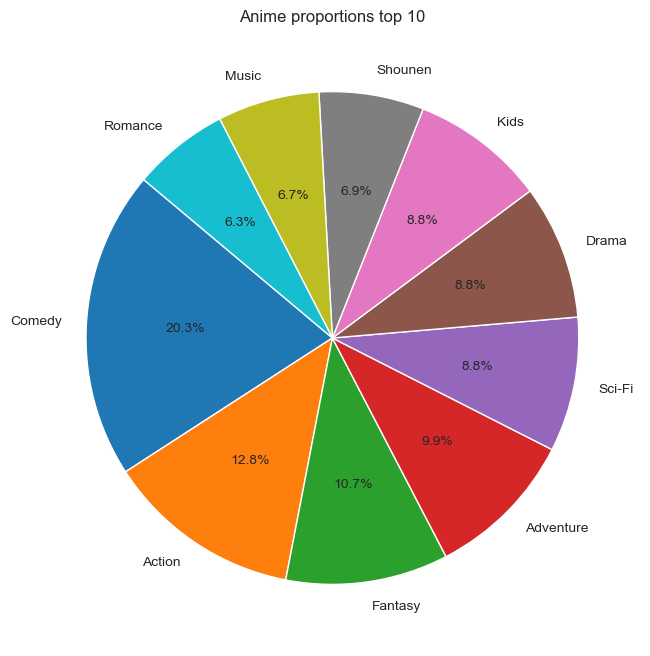

In [6]:
plt.figure(figsize=(8,8))
plt.pie(top_genres, labels=top_genres.index, autopct='%1.1f%%', startangle=140)
plt.title("Anime proportions top 10")
plt.show()

<Axes: xlabel='ranked', ylabel='Count'>

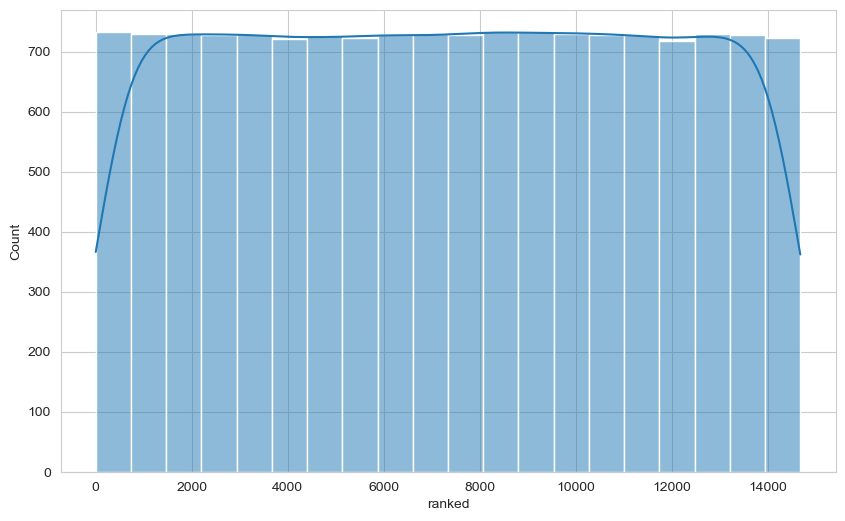

In [10]:
sns.histplot(df_anime['ranked'], bins=20, kde=True)

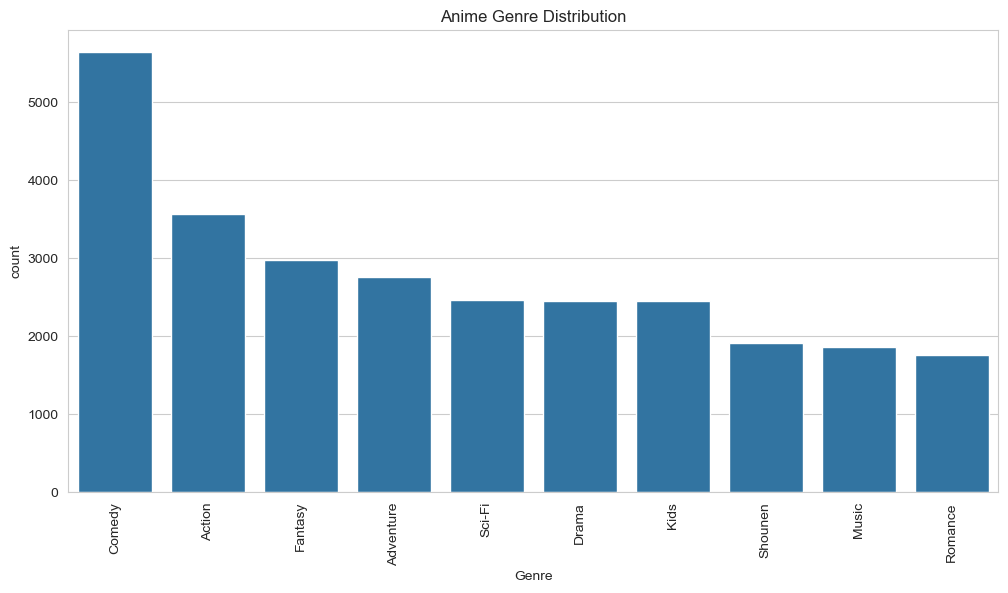

In [18]:
# Make sure 'genre' is list type
df_anime['genre'] = df_anime['genre'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# Explode into one genre per row
df_genre_exploded = df_anime.explode('genre').reset_index(drop=True)
top_genres = df_genre_exploded['genre'].value_counts().head(10)

# Plot again
import matplotlib.pyplot as plt
import seaborn as sns

df_genre = pd.DataFrame({
    "Genre" : top_genres.index,
    "count" : top_genres.values
})

plt.figure(figsize=(12,6))
sns.barplot(x= 'Genre', y = 'count', data=df_genre)
plt.xticks(rotation=90)
plt.title("Anime Genre Distribution")
plt.show()


In [9]:
genre_counts = df_genre_exploded['genre'].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(10,5))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.title("Top 10 Anime Genres (in %)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()


KeyError: 'genre'